# Extrapolate SKedge nexafs to perfect molecular orientation

## Setup

### Imports

In [1]:
# Imports:
import sys
import pathlib
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib as mpl
from matplotlib.ticker import MultipleLocator
import xarray as xr
import pandas as pd
import dask.array as da
# import kkcalc
# from kkcalc import data
# from kkcalc import kk
from kkcalc.models import *
from kkcalc import stoichiometry
import xraydb
from scipy import optimize
from tqdm.auto import tqdm

basePath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite')
nexafsFxnsPath = basePath.joinpath('misc_older_work/nexafs_analysis')
sys.path.append(str(nexafsFxnsPath))
import nexafs_fxns as nf  # custom nexafs functions used throughout this notebook

### Define paths/objects

In [2]:
basePath = pathlib.Path('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite')
nfZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/fl_nexafs_zarrs')
lpZarrsPath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/lamella_vs_energy_zarrs')

nfZarrsPath.exists()

True

## Load and check NEXAFS data

### Load NEXAF data

In [3]:
# Define path to zarr
nfZarrPath = sorted(nfZarrsPath.glob('*.zarr'))[0]
nfZarrPath

PosixPath('/Users/andrew/Library/CloudStorage/OneDrive-UCB-O365/research/data_analysis/rsoxs_suite/local_data/trexs_nexafs_2024C3/waxs_all/fl_nexafs_zarrs/fl_nexafs_v1.zarr')

In [4]:
# Load zarr into xarray
nf_DA = xr.open_zarr(nfZarrPath)['fl_nexafs'].compute()
nf_DA = nf_DA.assign_coords({'cos_sq_theta': ('theta', np.round(((np.cos(np.deg2rad(nf_DA.theta)))**2), 5).data)})
nf_DA

<xarray.DataArray 'fl_nexafs' (sample_ID: 9, theta: 3, energy: 45)> Size: 10kB
array([[[-0.41077058, -0.22078365, -0.09513144, ...,  0.79223524,
          0.92340233,  1.07659767],
        [-0.38961043, -0.19134175, -0.08593922, ...,  0.71107445,
          0.89666805,  1.10333195],
        [-0.34402685, -0.17011382, -0.09002547, ...,  0.7819778 ,
          0.91762148,  1.08237852]],

       [[ 0.10228803,  0.04490482,  0.01953648, ...,  1.17958607,
          1.03764692,  0.96235308],
        [ 0.10915128,  0.05596543,  0.02511987, ...,  1.18744964,
          1.04508585,  0.95491415],
        [ 0.12750074,  0.06590075,  0.02672047, ...,  1.15813531,
          1.03866026,  0.96133974]],

       [[ 0.18951458,  0.08400359,  0.04673   , ...,  1.2949463 ,
          1.06346472,  0.93653528],
        [ 0.17156163,  0.10004697,  0.04187024, ...,  1.30667703,
          1.08297332,  0.91702668],
        [ 0.15791765,  0.07689307,  0.0335237 , ...,  1.3034102 ,
          1.09416705,  0.90583295]],
...
       [[ 0.14945225,  0.08195294,  0.04517896, ...,  1.34466475,
          1.07576707,  0.92423293],
        [ 0.14645657,  0.0645724 ,  0.03608419, ...,  1.32968515,
          1.0754926 ,  0.9245074 ],
        [ 0.14804235,  0.07174848,  0.03535522, ...,  1.35019004,
          1.08819968,  0.91180032]],

       [[ 0.13059418,  0.06230301,  0.03569537, ...,  1.25723169,
          1.05379416,  0.94620584],
        [ 0.13041309,  0.06037626,  0.02721031, ...,  1.27091495,
          1.07389298,  0.92610702],
        [ 0.11438393,  0.05145012,  0.02475699, ...,  1.27919868,
          1.08385719,  0.91614281]],

       [[ 0.15043043,  0.06961586,  0.03249948, ...,  1.26444866,
          1.05147112,  0.94852888],
        [ 0.1373164 ,  0.07250496,  0.03372843, ...,  1.26745804,
          1.07581778,  0.92418222],
        [ 0.14371947,  0.07094518,  0.0327005 , ...,  1.28125285,
          1.07651698,  0.92348302]]])
Coordinates:
  * energy        (energy) float64 360B 2.442e+03 2.447e+03 ... 2.517e+03
  * sample_ID     (sample_ID) <U5 180B 'SiN-0' 'SiN-1' ... 'SiN-7' 'SiN-8'
  * theta         (theta) int64 24B 90 55 35
    cos_sq_theta  (theta) float64 24B 0.0 0.329 0.671

In [5]:
# Initalize dictionaries for sample names (for titles & saving files)
sn = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7 CF + 0.0% CN',
    'SiN-2': 'PM7 CF + 5.0% CN',
    'SiN-3': 'PM6 CF + 0.0% CN',
    'SiN-4': 'PM6 CF + 5.0% CN',
    'SiN-5': 'PM7 CF + 1.0% CN',
    'SiN-6': 'PM7 CF + 0.5% CN',
    'SiN-7': 'PM6 CF + 1.0% CN',
    'SiN-8': 'PM6 CF + 0.5% CN',    
}

sn_id = {
    'SiN-0': 'BareSiN',
    'SiN-1': 'PM7_CF',
    'SiN-2': 'PM7_5CN-CF',
    'SiN-3': 'PM6_CF',
    'SiN-4': 'PM6_5CN-CF',
    'SiN-5': 'PM7_1CN-CF',
    'SiN-6': 'PM7_p5CN-CF',
    'SiN-7': 'PM6_1CN-CF',
    'SiN-8': 'PM6_p5CN-CF',
}

### Plot experimental data

In [6]:
print('hi')

hi


  0%|          | 0/9 [00:00<?, ?it/s]

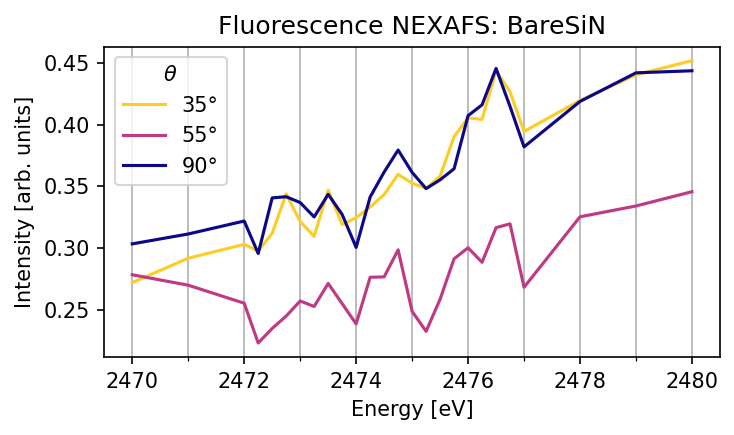

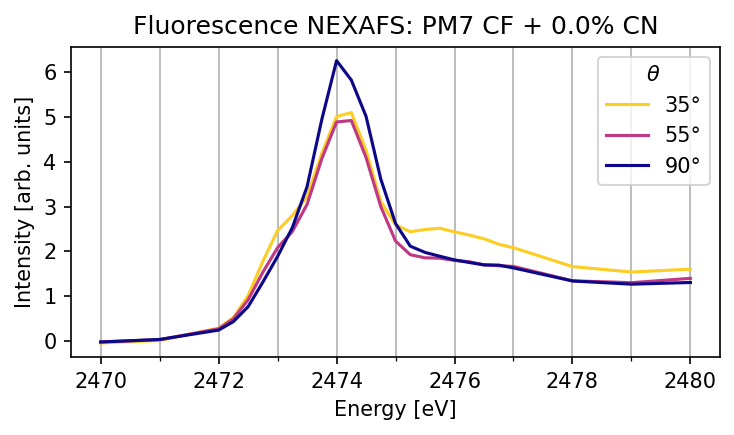

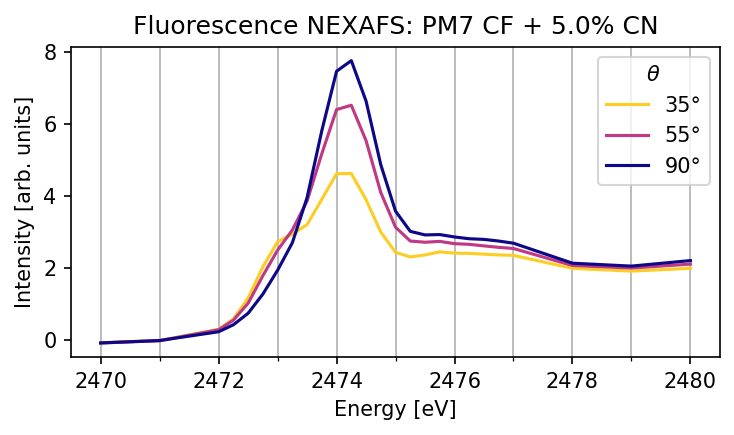

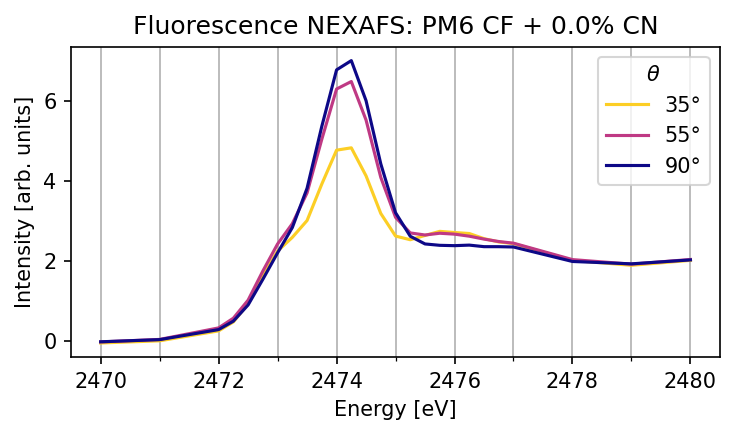

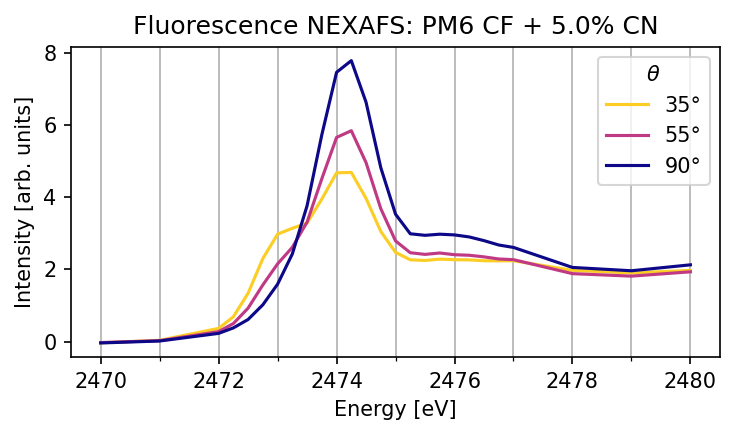

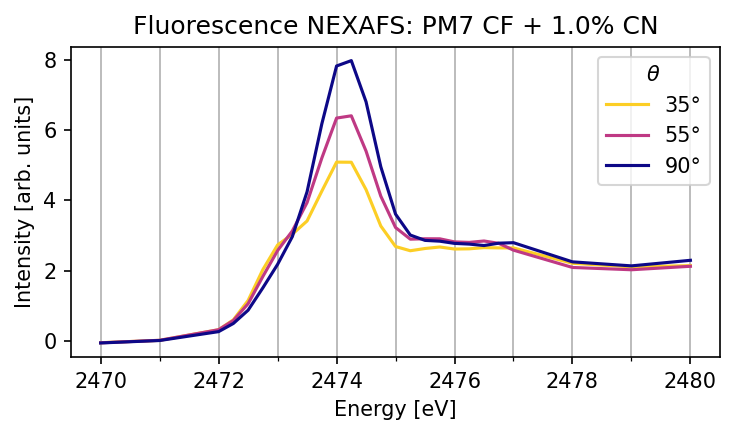

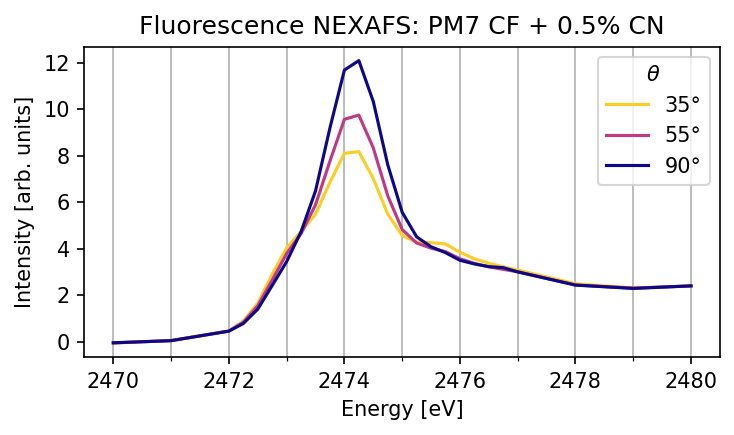

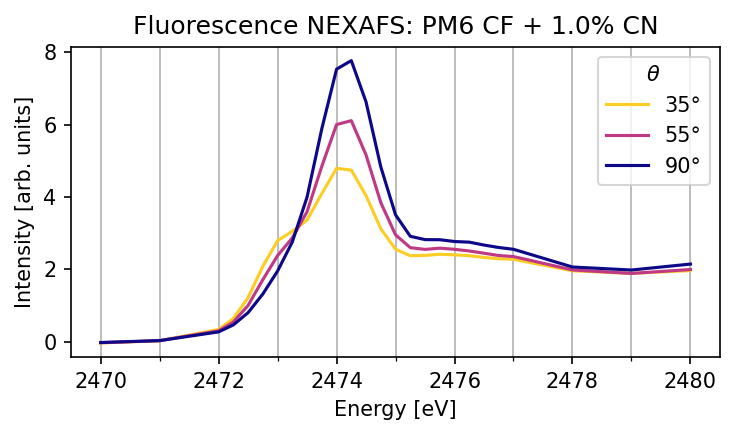

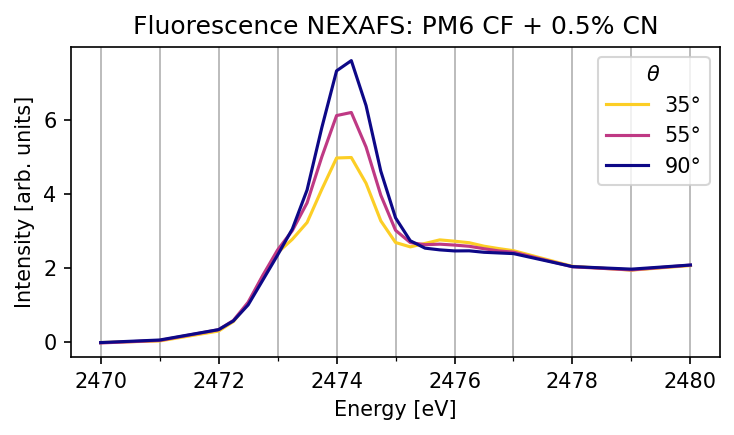

In [32]:
%matplotlib inline
plt.close('all')

# Plot all incident angles NEXAFS for each sample

# Select energy slice(s)
# e_slice = slice(2460, 2510)
# e_slice = slice(2445, 2520)
# e_slice = slice(2470, 2495)
e_slice = slice(2470, 2480)


# colors = plt.cm.viridis_r(np.linspace(0.1,1,3))
colors = plt.cm.plasma_r(np.linspace(0.1,1,3))
for sample_ID in tqdm(nf_DA.sample_ID.values[:]):
    fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True, dpi=150)
    for i, theta in enumerate([35, 55, 90]):
        # Plot    
        nf_DA.sel(sample_ID=sample_ID, energy=e_slice, theta=theta).plot.line(ax=ax, label=f'{theta}°', color=colors[i])
                                                                        # linestyle='none', marker='.')

    ax.set_title(f'Fluorescence NEXAFS: {sn[sample_ID]}')
    ax.set(ylabel=f'Intensity [arb. units]', xlabel='Energy [eV]')

    # ax.xaxis.set_minor_locator(MultipleLocator(5))
    # ax.xaxis.set_major_locator(MultipleLocator(10))
    
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.grid(True, which='both')
    ax.legend(title='$\\theta$')

    # savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/fl_nexafs_v2')
    # savePath.mkdir(exist_ok=True)
    # fig.savefig(savePath.joinpath(
    #     f'{sn_id[sample_ID]}_avg-roi-nexafs_energy-{e_slice.start}-{e_slice.stop}.png'), dpi=150)

    plt.show()
    plt.close('all')

### Molecular tilt fit:

In [16]:
DA

<xarray.DataArray 'fl_nexafs' (theta: 3, energy: 45)> Size: 1kB
array([[ 1.50430426e-01,  6.96158585e-02,  3.24994759e-02,
         1.07689708e-03, -3.35763730e-02, -4.31153883e-02,
        -3.80805231e-02, -4.01930603e-02, -2.05655736e-02,
         4.81137081e-02,  3.28813013e-01,  5.63455677e-01,
         9.94658058e-01,  1.66776978e+00,  2.34178286e+00,
         3.04555031e+00,  4.09945614e+00,  5.78349176e+00,
         7.31564460e+00,  7.59146048e+00,  6.37833081e+00,
         4.60710855e+00,  3.34654335e+00,  2.72767267e+00,
         2.52833098e+00,  2.48193213e+00,  2.45338607e+00,
         2.45624303e+00,  2.41662142e+00,  2.39875467e+00,
         2.38089637e+00,  2.02968670e+00,  1.96163051e+00,
         2.07294839e+00,  2.11382553e+00,  2.07977883e+00,
         2.03861129e+00,  2.00019381e+00,  1.92640113e+00,
         1.89710943e+00,  1.88925918e+00,  1.53176636e+00,
         1.26444866e+00,  1.05147112e+00,  9.48528880e-01],
       [ 1.37316397e-01,  7.25049594e-02,  3.37284312e-02,
         2.48014375e-03, -3.62085749e-02, -4.79323980e-02,
        -5.75525694e-02, -5.66833228e-02, -3.15858047e-02,
         3.62826639e-02,  3.26421448e-01,  5.76232769e-01,
         1.06651813e+00,  1.79630138e+00,  2.47940913e+00,
...
         2.41968890e+00,  2.02518307e+00,  1.94074989e+00,
         2.07056726e+00,  2.15455984e+00,  2.10771352e+00,
         2.05004244e+00,  1.97105801e+00,  1.89355392e+00,
         1.85631786e+00,  1.86136632e+00,  1.52673748e+00,
         1.26745804e+00,  1.07581778e+00,  9.24182219e-01],
       [ 1.43719470e-01,  7.09451839e-02,  3.27005050e-02,
        -1.01130311e-03, -3.16892019e-02, -4.53132740e-02,
        -5.11386954e-02, -4.69674502e-02, -2.03337579e-02,
         2.29588802e-02,  2.90340890e-01,  5.45470389e-01,
         1.03448252e+00,  1.77454411e+00,  2.40433331e+00,
         2.76858604e+00,  3.22074424e+00,  4.11630084e+00,
         4.96266592e+00,  4.97546031e+00,  4.28024269e+00,
         3.26564339e+00,  2.68058353e+00,  2.56280240e+00,
         2.65541885e+00,  2.75142326e+00,  2.71579013e+00,
         2.67479567e+00,  2.58095033e+00,  2.51622828e+00,
         2.45960512e+00,  2.03845929e+00,  1.93449561e+00,
         2.05858019e+00,  2.16284556e+00,  2.11520439e+00,
         2.05341149e+00,  1.94711031e+00,  1.86527861e+00,
         1.81643060e+00,  1.82851690e+00,  1.52949222e+00,
         1.28125285e+00,  1.07651698e+00,  9.23483020e-01]])
Coordinates:
  * energy        (energy) float64 360B 2.442e+03 2.447e+03 ... 2.517e+03
    sample_ID     <U5 20B 'SiN-8'
  * theta         (theta) int64 24B 90 55 35
    cos_sq_theta  (theta) float64 24B 0.0 0.329 0.671

In [22]:
DA

<xarray.DataArray 'electron_yield' (theta: 4, energy: 45)> Size: 1kB
array([[ 1.47092688e-01,  7.03760265e-02,  3.28835420e-02,
         1.90152743e-03, -3.47850694e-02, -4.43859020e-02,
        -4.25211449e-02, -4.46673515e-02, -2.43484620e-02,
         4.82843154e-02,  3.34409244e-01,  5.70792908e-01,
         1.01243941e+00,  1.69365335e+00,  2.37812340e+00,
         3.07670453e+00,  4.12766499e+00,  5.79260532e+00,
         7.29725208e+00,  7.55153629e+00,  6.34735121e+00,
         4.61001699e+00,  3.34341030e+00,  2.73859091e+00,
         2.53886707e+00,  2.48930816e+00,  2.46329964e+00,
         2.46138298e+00,  2.42187566e+00,  2.39787304e+00,
         2.38096513e+00,  2.02669516e+00,  1.95905625e+00,
         2.07453286e+00,  2.11949966e+00,  2.08336872e+00,
         2.04002972e+00,  1.99913733e+00,  1.92542282e+00,
         1.89668966e+00,  1.88990083e+00,  1.53043656e+00,
         1.26267185e+00,  1.05557101e+00,  9.44428986e-01],
       [ 1.43864714e-01,  7.10135836e-02,  3.29749308e-02,
         8.62299157e-04, -3.38372300e-02, -4.54397735e-02,
        -4.88405010e-02, -4.79051983e-02, -2.41641454e-02,
         3.59479491e-02,  3.15442187e-01,  5.61837837e-01,
         1.03163284e+00,  1.74552034e+00,  2.40811251e+00,
...
         2.45967125e+00,  2.03558173e+00,  1.93201942e+00,
         2.06010430e+00,  2.16830352e+00,  2.11865752e+00,
         2.05477588e+00,  1.94609408e+00,  1.86433756e+00,
         1.81602682e+00,  1.82913411e+00,  1.52821308e+00,
         1.27954373e+00,  1.08046068e+00,  9.19539320e-01],
       [ 1.37280917e-01,  7.23139487e-02,  3.31613280e-02,
        -1.25731713e-03, -3.19040109e-02, -4.75892562e-02,
        -6.17294981e-02, -5.45091303e-02, -2.37882123e-02,
         1.07866215e-02,  2.76756864e-01,  5.43573021e-01,
         1.07077988e+00,  1.85130857e+00,  2.46927849e+00,
         2.66217843e+00,  2.81652719e+00,  3.30748868e+00,
         3.79167396e+00,  3.65520215e+00,  3.22234878e+00,
         2.61067872e+00,  2.35111443e+00,  2.49226637e+00,
         2.72766675e+00,  2.89050951e+00,  2.85379513e+00,
         2.78679813e+00,  2.66647519e+00,  2.57299293e+00,
         2.49826014e+00,  2.03993873e+00,  1.91876352e+00,
         2.05303011e+00,  2.19223161e+00,  2.13595929e+00,
         2.06200579e+00,  1.92008746e+00,  1.83438803e+00,
         1.77647857e+00,  1.79934075e+00,  1.52712293e+00,
         1.28781586e+00,  1.09266385e+00,  9.07336147e-01]])
Coordinates:
    sample_ID     <U5 20B 'SiN-8'
  * energy        (energy) float64 360B 2.442e+03 2.447e+03 ... 2.517e+03
    cos_sq_theta  (theta) float64 32B 0.0 0.329 0.671 1.0
  * theta         (theta) int64 32B 90 55 35 0
Attributes:
    unit:     a.u.

In [33]:
y_fits_DA

<xarray.DataArray 'electron_yield' (theta: 3, energy: 45)> Size: 1kB
array([[-73.80798467, -61.47639454, -49.1448044 , -36.81321426,
        -24.48162413, -12.15003399,  -9.68371596,  -7.21739794,
         -4.75107991,  -2.28476188,   0.18155615,   0.79813565,
          1.41471516,   2.03129467,   2.64787417,   3.26445368,
          3.88103319,   4.49761269,   5.1141922 ,   5.73077171,
          6.34735121,   6.96393072,   7.58051023,   8.19708973,
          8.81366924,   9.43024875,  10.04682825,  10.66340776,
         11.27998727,  11.89656677,  12.51314628,  14.97946431,
         17.44578234,  19.91210036,  22.37841839,  24.84473642,
         27.31105445,  29.77737247,  32.2436905 ,  34.71000853,
         37.17632655,  49.50791669,  61.83950683,  86.5026871 ,
        111.16586737],
       [-53.28701466, -44.27066523, -35.25431579, -26.23796636,
        -17.22161692,  -8.20526749,  -6.4019976 ,  -4.59872772,
         -2.79545783,  -0.99218794,   0.81108194,   1.26189942,
          1.71271689,   2.16353436,   2.61435183,   3.0651693 ,
          3.51598677,   3.96680425,   4.41762172,   4.86843919,
          5.31925666,   5.77007413,   6.2208916 ,   6.67170908,
          7.12252655,   7.57334402,   8.02416149,   8.47497896,
          8.92579643,   9.37661391,   9.82743138,  11.63070127,
         13.43397115,  15.23724104,  17.04051093,  18.84378081,
         20.6470507 ,  22.45032059,  24.25359047,  26.05686036,
         27.86013025,  36.87647968,  45.89282911,  63.92552798,
         81.95822685],
       [-31.95328973, -26.38348465, -20.81367956, -15.24387447,
         -9.67406939,  -4.1042643 ,  -2.99030328,  -1.87634227,
         -0.76238125,   0.35157977,   1.46554078,   1.74403104,
          2.02252129,   2.30101155,   2.5795018 ,   2.85799206,
          3.13648231,   3.41497256,   3.69346282,   3.97195307,
          4.25044333,   4.52893358,   4.80742384,   5.08591409,
          5.36440434,   5.6428946 ,   5.92138485,   6.19987511,
          6.47836536,   6.75685562,   7.03534587,   8.14930689,
          9.26326791,  10.37722892,  11.49118994,  12.60515096,
         13.71911197,  14.83307299,  15.94703401,  17.06099503,
         18.17495604,  23.74476113,  29.31456621,  40.45417639,
         51.59378656]])
Coordinates:
    sample_ID     <U5 20B 'SiN-8'
  * energy        (energy) float64 360B 2.442e+03 2.447e+03 ... 2.517e+03
    cos_sq_theta  (theta) float64 24B 0.0 0.329 0.671
  * theta         (theta) int64 24B 90 55 35
Attributes:
    unit:     a.u.

2473.6to2474.9 bounds:   0%|          | 0/9 [00:00<?, ?it/s]

[2.66380698 2.32531513 1.50561436]


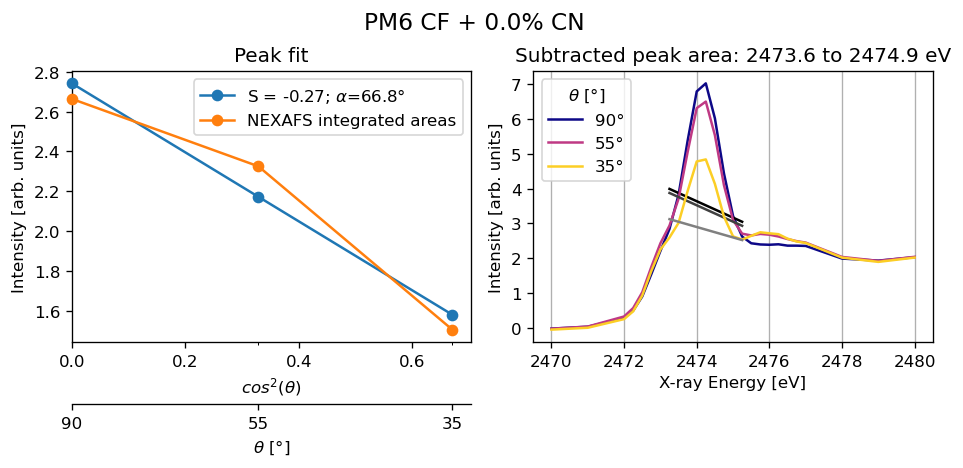

[3.13898064 2.08699151 1.32852639]


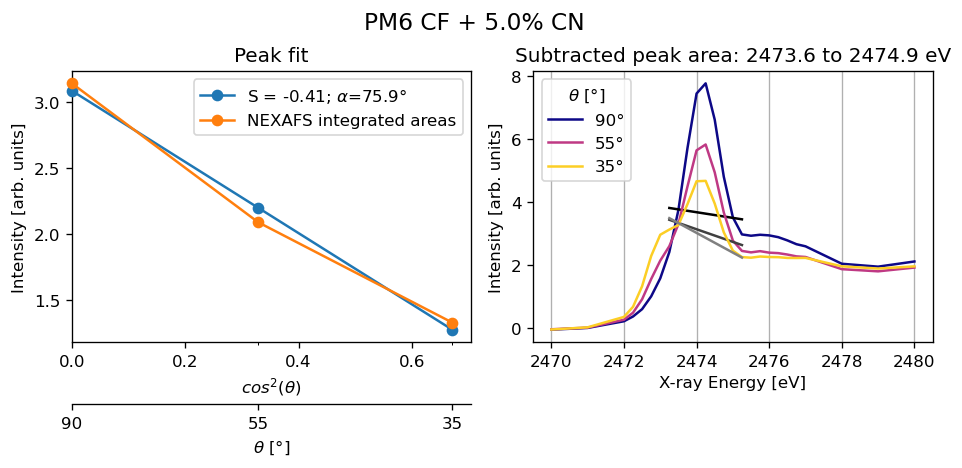

[3.06879222 2.12932705 1.33628339]


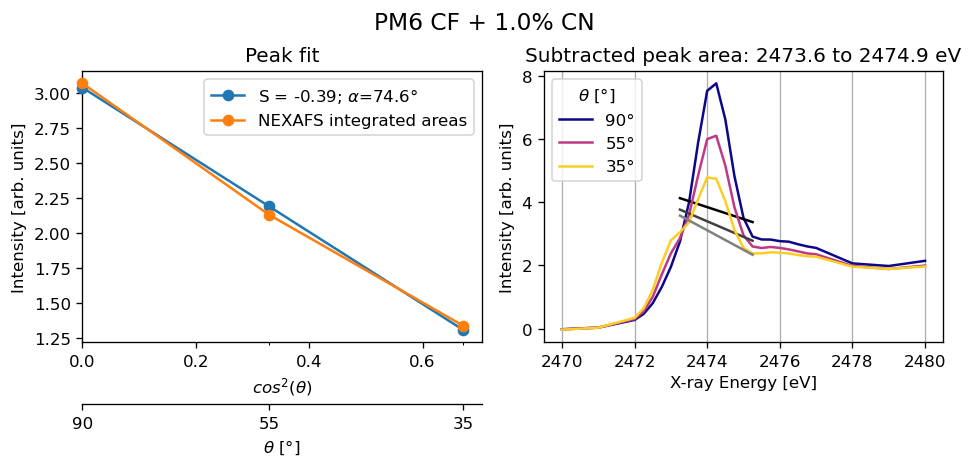

[2.89718427 2.12705078 1.52667137]


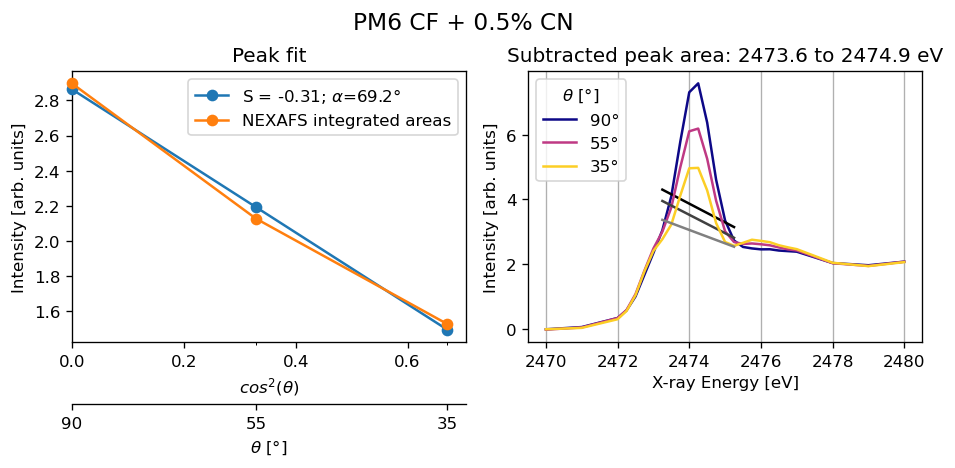

In [100]:
# Run Stöhr 9.16a tilt fit on energy region of NEXAFS
edge = 'carbon'
nexafs_type = 'tey'
# nexafs_type = 'trmsn'

for e_min, e_max in [(2473.6, 2474.9)]:  # carbon peak area bounds
    for sample_ID in tqdm(nf_DA.sample_ID.values[:], desc=f'{e_min}to{e_max} bounds'):
    # for sample_ID in tqdm(nf_ep_DA.sample_ID.values[:], desc=f'{e_min}to{e_max} bounds'):
    # for sample_name in tqdm(sample_names, desc=f'{e_min}to{e_max} bounds'):
        # nf_DA = DS[f'full_corr_{nexafs_type}'].sel(sample_name=sample_names
        
        if 'PM6' in sn[sample_ID]:
            DA = nf_DA.sel(sample_ID=sample_ID)
            # DA = DA.swap_dims({'cos_sq_theta':'theta'})
            # DA = DA.sel(theta=[90, 55, 35])
    
            # Draw y_fits
            points_x = [e_min, e_max]
            x_tol = 0
            # points_y = [DA.sel(energy=slice(points_x[0]-x_tol, points_x[0]+x_tol)).mean('energy'), 
            #             DA.sel(energy=slice(points_x[1]-x_tol, points_x[1]+x_tol)).mean('energy')]
            points_y = [DA.sel(energy=points_x[0], method='nearest'), 
                        DA.sel(energy=points_x[1], method='nearest')]
            m_DA = (points_y[1]-points_y[0])/(points_x[1]-points_x[0])
            b_DA = points_y[1] - (m_DA*points_x[1])
            y_fits = np.empty((0,len(DA.energy)), float)
            
            for m, b in zip(m_DA.compute().data, b_DA.compute().data):
                y_fit = np.polyval([m, b], DA.energy).reshape(1, len(DA.energy))
                y_fits = np.append(y_fits, y_fit, axis=0)
            
            y_fits_DA = DA.copy()
            y_fits_DA.data = y_fits
    
            sub_DA = DA - y_fits_DA
            
            pi_peak_areas = nf.int_area(e_min, e_max, sub_DA)
            print(pi_peak_areas)
    
            bnds = [(0, 90), (0, 50)]
            res = optimize.differential_evolution(
                nf.mse_line_tilt, bounds=bnds, args=(pi_peak_areas, DA.theta.values), tol=1e-6)
    
            alpha, const = res.x

            S = 0.5 * (3*np.cos(np.deg2rad(alpha))**2 - 1)
    
            # Plot intensities from Stöhr 9.16a (scaled with fitted constant) as line
            # along with measured pi_peak_areas, x-axis is cos_sq_theta:
            fig, axs = plt.subplots(ncols=2, figsize=(8,4), dpi=120, tight_layout=True)
            fig.suptitle(sn[str(DA.sample_ID.values)], y=0.95, fontsize=14)
            axs[0].plot(DA.cos_sq_theta.values[:], const * nf.i_nexafs(alpha, DA.theta.values[:]),
                    marker='o', label=f'S = {np.round(S,2)}; $\\alpha$={np.round(alpha,1)}°',
                    clip_on=False, zorder=3)
            axs[0].plot(DA.cos_sq_theta.values[:], pi_peak_areas[:], marker='o',
                    label=f'NEXAFS integrated areas', clip_on=False, zorder=4)
            axs[0].set(title='Peak fit', xlabel=r'$cos^2(\theta)$', ylabel='Intensity [arb. units]')
            axs[0].set_xticks(DA.cos_sq_theta.values, minor=True)
            axs[0].set_xlim(left=0)
            # axs[0].set_ylim((0.7,1.9))
            axs[0].legend()
    
            # Add secondary axis showing theta values:
            def forward(x):
                return np.arccos(np.sqrt(x)) * 180 / np.pi
    
            def inverse(x):
                return np.cos(x * np.pi / 180)**2
    
            ax2 = axs[0].secondary_xaxis(-0.23, functions=(forward, inverse))
            ax2.set(xlabel=r'$\theta$ [$\degree$]')
            ax2.set_xticks(DA.theta.values)
    
    
            colors = plt.cm.plasma(np.linspace(0,0.9,len(DA.theta)))
            grey_colors = plt.cm.gray(np.linspace(0,0.5,len(DA.theta)))
            for i, theta_val in enumerate(DA.theta.values):
                (DA.sel(theta=theta_val, energy=slice(2470, 2480))
                       .plot.line(ax=axs[1], color=colors[i], label=f'{int(theta_val)}°'))
                (y_fits_DA.sel(theta=theta_val, energy=slice(e_min-0.4, e_max+0.38))
                       .plot.line(ax=axs[1], color=grey_colors[i]))
            # axs[1].axvline(e_min, color='grey')
            # axs[1].axvline(e_max, color='grey')
            axs[1].set(title=f'Subtracted peak area: {e_min} to {e_max} eV', xlabel='X-ray Energy [eV]', ylabel='Intensity [arb. units]')
            axs[1].grid(visible=True, axis='x')
            axs[1].legend(title=r'$\theta$ [$\degree$]', loc='upper left')
            
            savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/fl_nexafs_tilt_fits_v1')
            savePath.mkdir(exist_ok=True)
            fig.savefig(savePath.joinpath(f'{sn_id[sample_ID]}_avg-roi-nexafs_energy-{e_slice.start}-{e_slice.stop}_peak_range-{e_min}-{e_max}.png'), dpi=150)
    
            plt.show()
            plt.close('all')

In [12]:
DA

<xarray.DataArray 'electron_yield' (cos_sq_theta: 4, energy: 45)> Size: 1kB
array([[ 1.20412143e-01,  5.52311834e-02,  4.04053495e-02,
         2.12732077e-03, -4.25326703e-02, -5.02156403e-02,
        -4.15085791e-02, -3.06844669e-02, -1.63950161e-02,
         4.04399397e-02,  3.04911481e-01,  5.24652333e-01,
         9.38725088e-01,  1.59934453e+00,  2.27560064e+00,
         2.91465502e+00,  3.91996925e+00,  5.50666857e+00,
         6.96023977e+00,  7.20554435e+00,  6.16512091e+00,
         4.52527185e+00,  3.26999860e+00,  2.66413990e+00,
         2.47007103e+00,  2.43960849e+00,  2.42975462e+00,
         2.42795874e+00,  2.39240497e+00,  2.38500732e+00,
         2.37168480e+00,  2.00197515e+00,  1.93483264e+00,
         2.03510376e+00,  2.08885453e+00,  2.05289392e+00,
         2.02878590e+00,  2.00144361e+00,  1.96383641e+00,
         2.00317733e+00,  2.10793182e+00,  1.64734197e+00,
         1.29408667e+00,  1.07199143e+00,  9.28008574e-01],
       [ 1.17338190e-01,  5.51218369e-02,  3.26886968e-02,
         5.14629521e-03, -3.78349920e-02, -4.91481295e-02,
        -4.63802193e-02, -3.24671681e-02, -3.09044415e-02,
         2.58537618e-02,  2.88695890e-01,  5.14620848e-01,
         9.50551116e-01,  1.64235956e+00,  2.29536057e+00,
...
         2.45548423e+00,  2.02840679e+00,  1.89831614e+00,
         2.02391584e+00,  2.12037772e+00,  2.15080990e+00,
         2.07449204e+00,  1.96246472e+00,  1.89127226e+00,
         1.89471726e+00,  1.91559606e+00,  1.59295347e+00,
         1.31812585e+00,  1.07915390e+00,  9.20846098e-01],
       [ 1.11068537e-01,  5.48988132e-02,  1.69497652e-02,
         1.13038138e-02, -2.82535790e-02, -4.69708281e-02,
        -5.63164461e-02, -3.61031764e-02, -6.04979535e-02,
        -3.89629515e-03,  2.55622472e-01,  4.94160571e-01,
         9.74671556e-01,  1.73009327e+00,  2.33566304e+00,
         2.54317574e+00,  2.70971281e+00,  3.34416264e+00,
         3.95411450e+00,  3.94085768e+00,  3.35204747e+00,
         2.67033460e+00,  2.39488793e+00,  2.53294909e+00,
         2.78546840e+00,  2.95835237e+00,  2.91762260e+00,
         2.85890538e+00,  2.68977774e+00,  2.56193547e+00,
         2.49657031e+00,  2.04136598e+00,  1.88041244e+00,
         2.01843050e+00,  2.13583325e+00,  2.19881720e+00,
         2.09690133e+00,  1.94335372e+00,  1.85569473e+00,
         1.84154030e+00,  1.82129561e+00,  1.56628729e+00,
         1.32991204e+00,  1.08266560e+00,  9.17334403e-01]])
Coordinates:
    sample_ID     <U5 20B 'SiN-3'
  * energy        (energy) float64 360B 2.442e+03 2.447e+03 ... 2.517e+03
  * cos_sq_theta  (cos_sq_theta) float64 32B 0.0 0.329 0.671 1.0
    theta         (cos_sq_theta) int64 32B 90 55 35 0
Attributes:
    unit:     a.u.

In [41]:
str(DA.sample_ID.values)

'SiN-0'

## Extrapolate NEXAFS theta values (reach 0 degrees theta)

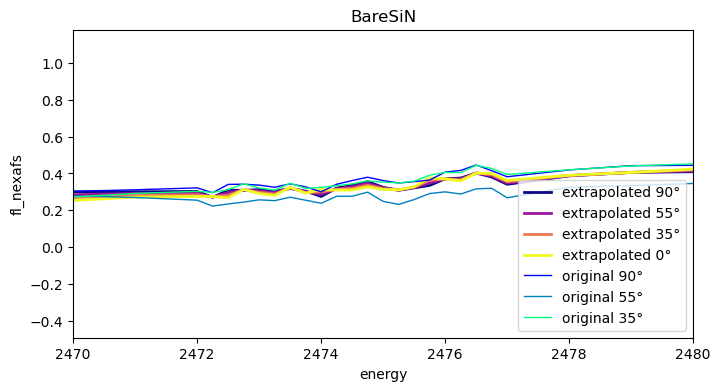

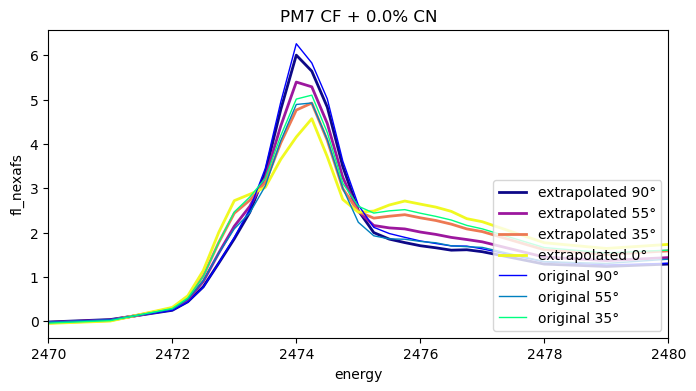

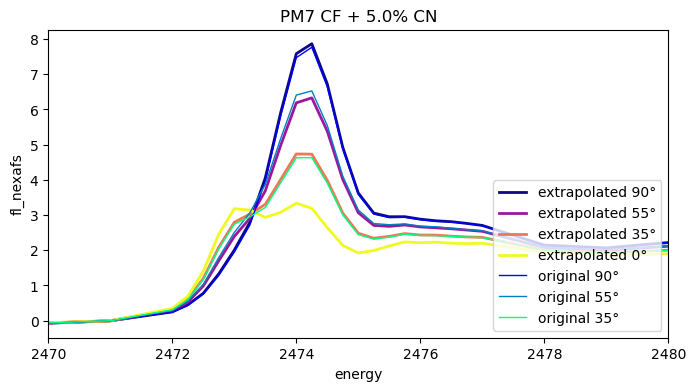

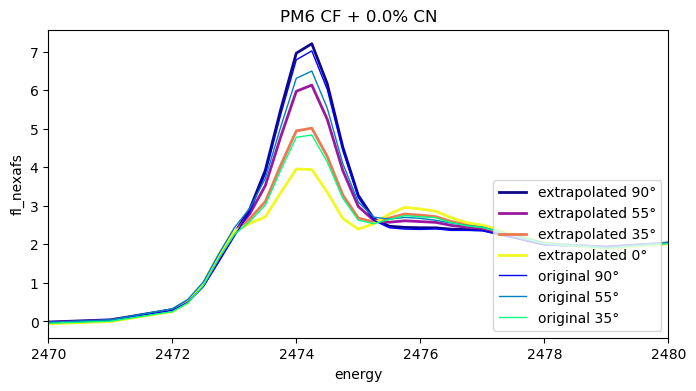

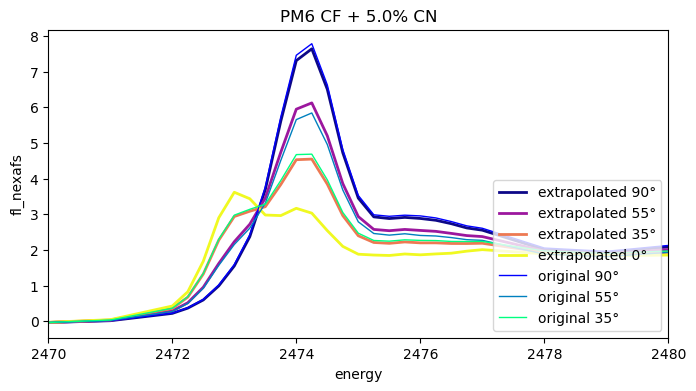

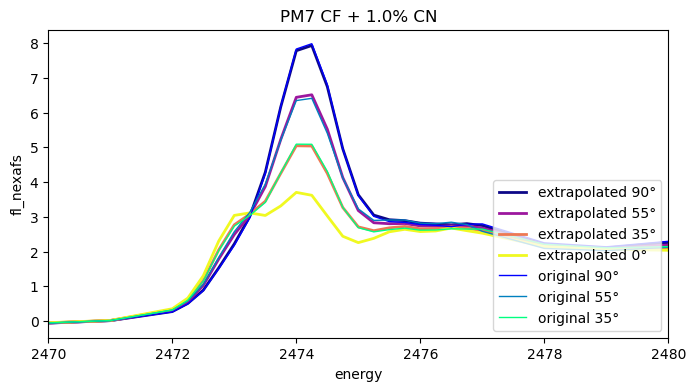

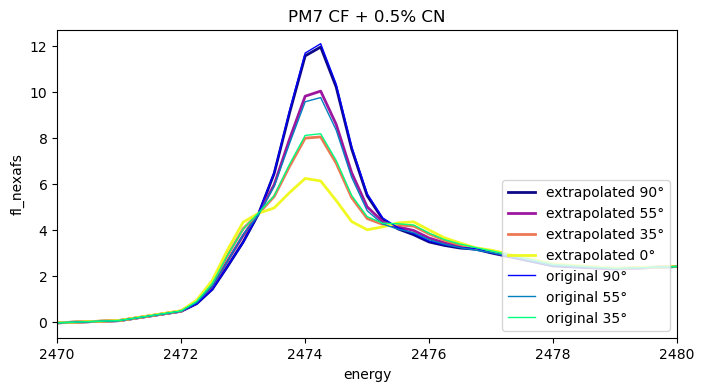

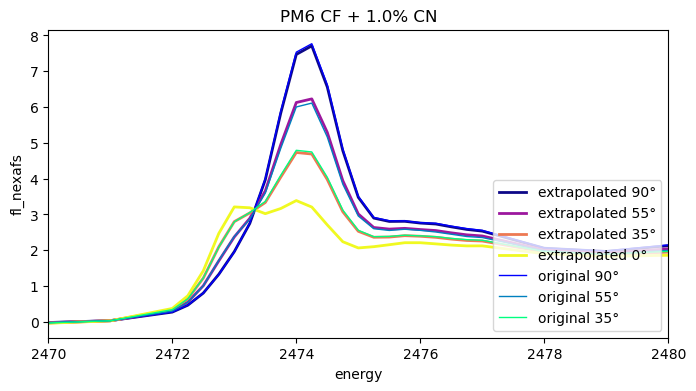

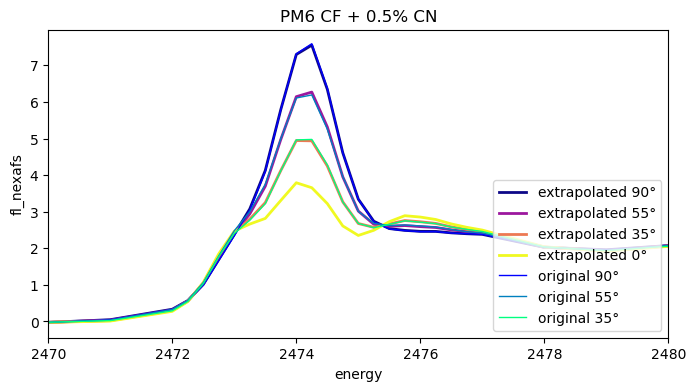

In [8]:
nexafs = nf_DA.swap_dims({'theta':'cos_sq_theta'})
nexafs_ep_rows = []
for sample_ID in nf_DA.sample_ID.values:
    DA = nf_DA.sel(sample_ID=sample_ID).copy()
    
    nexafs = DA.copy().swap_dims({'theta':'cos_sq_theta'}).squeeze()
    nexafs_fit = nexafs.polyfit('cos_sq_theta', 1)
    new_theta = np.append(DA.theta.values, 0)
    new_cos_sq_theta = np.round((np.cos(new_theta*np.pi/180))**2, 5)
    nexafs_ep = nf.evaluate_nexafs_fit(nexafs, nexafs_fit, new_cos_sq_theta, new_theta)   
    nexafs_ep = nexafs_ep.expand_dims({'sample_ID':[sample_ID]})
    nexafs_ep_rows.append(nexafs_ep['electron_yield'])
    
    
    fig, ax1 = plt.subplots(figsize=(8,4))
    #the xarray way of plotting
    colors = plt.cm.plasma(np.linspace(0,1,nexafs_ep.theta.size))
    colors2 = plt.cm.winter(np.linspace(0,1,nexafs.theta.size))
    for i, cos_sq_theta in enumerate(nexafs_ep.cos_sq_theta): 
        nexafs_ep.electron_yield.sel(cos_sq_theta=cos_sq_theta).plot(color = colors[i], lw = 2, label = f'extrapolated {nexafs_ep.theta[i].values}°')
    for i, cos_sq_theta in enumerate(nexafs.cos_sq_theta): 
        nexafs.sel(cos_sq_theta=cos_sq_theta).plot(color = colors2[i], lw = 1, label = f'original {nexafs.theta[i].values}°')
    # plt.title(nexafs.description)
    ax1.set_title(f'{sn[sample_ID]}')
    ax1.set_xlim(2470,2480)
    ax1.legend(loc='lower right')
    # plt.savefig(exportPath.joinpath(f'{nexafs_ep.name}_nexafs_theta_extrap.svg'))
    plt.show()
    plt.close('all')

nf_ep_DA = xr.concat(nexafs_ep_rows, dim='sample_ID')

  0%|          | 0/9 [00:00<?, ?it/s]

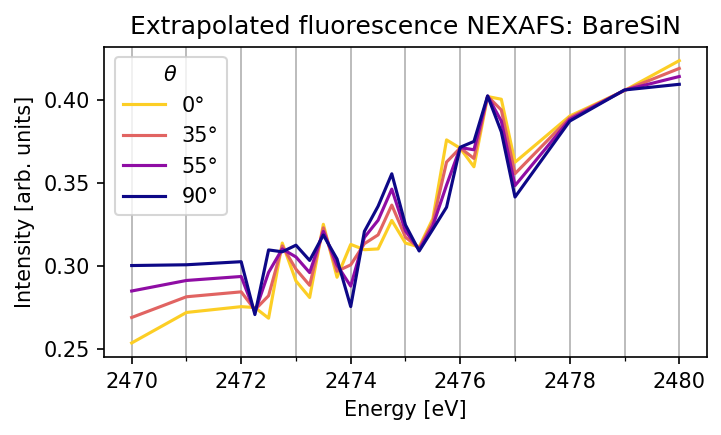

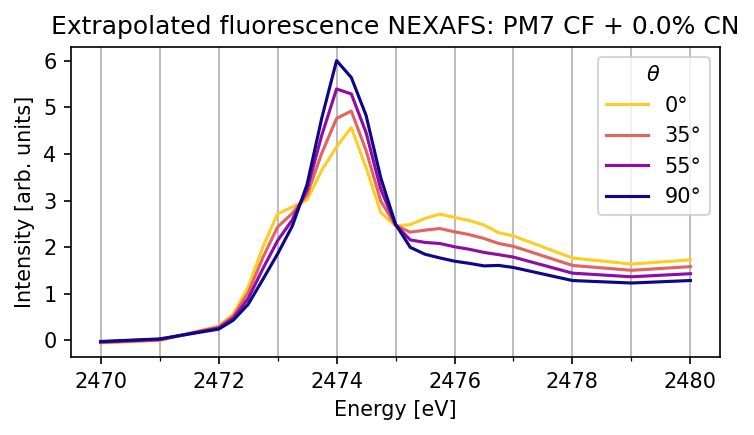

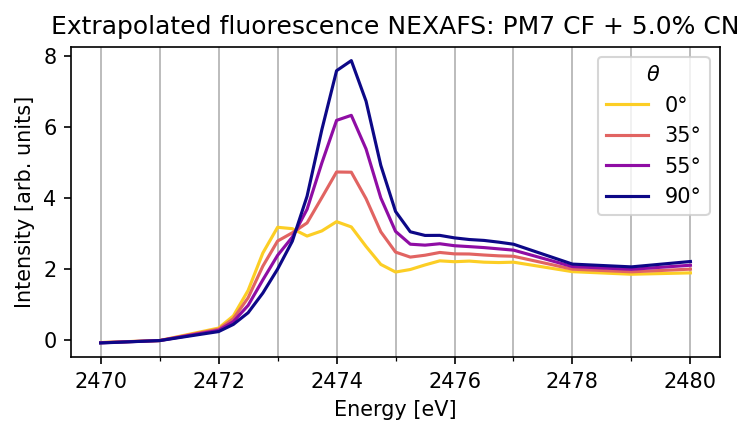

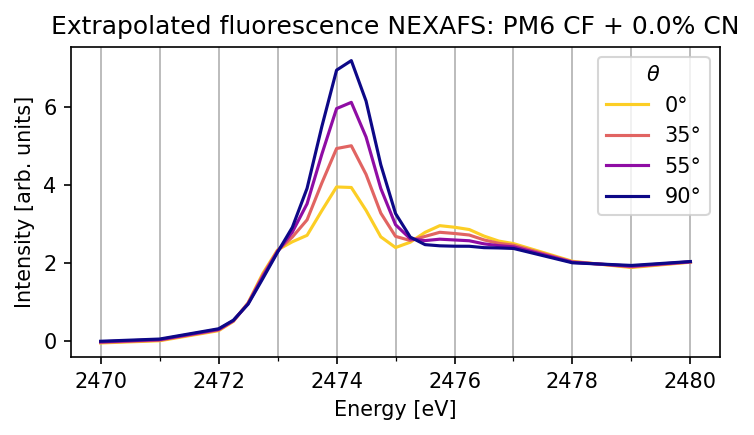

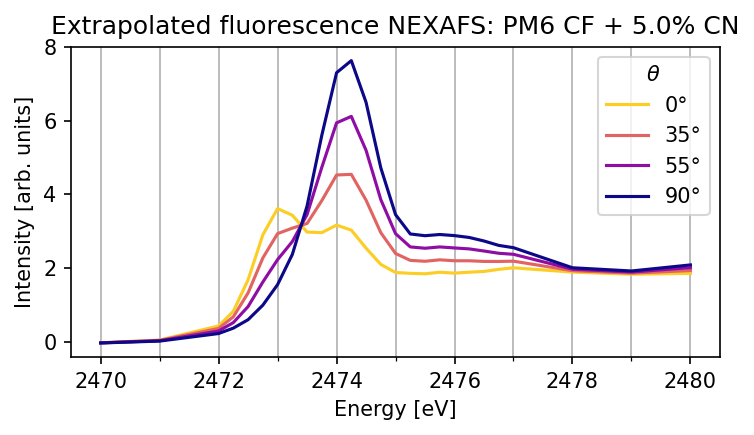

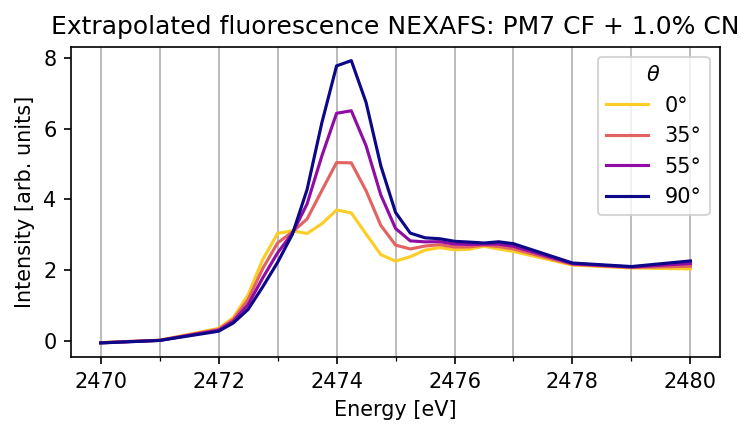

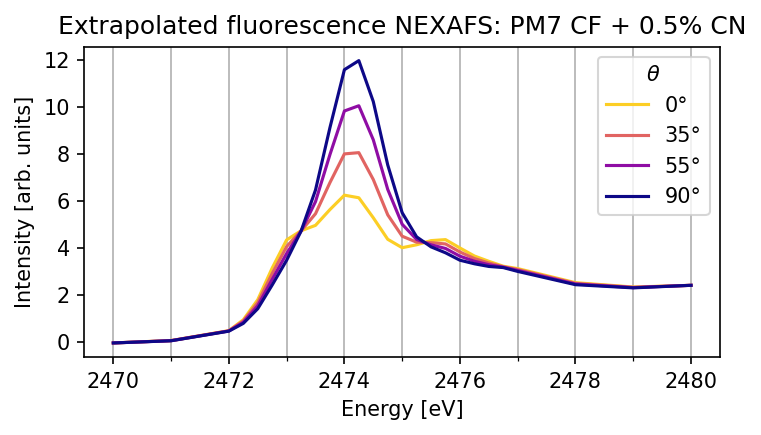

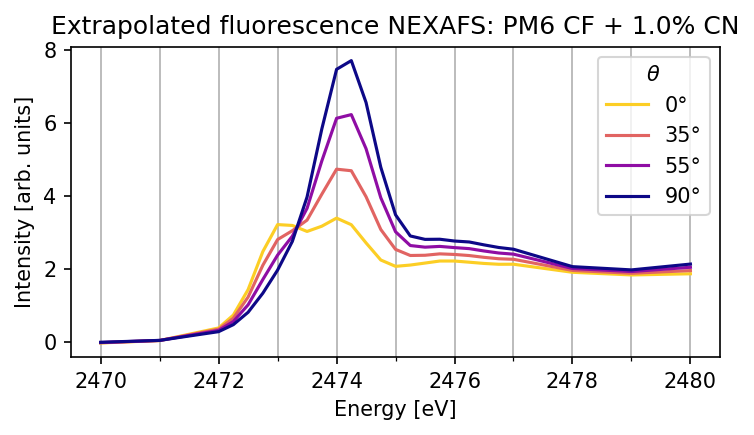

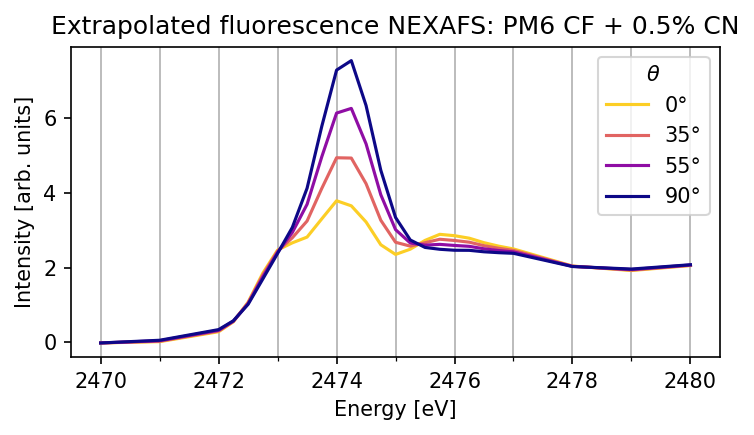

In [22]:
%matplotlib inline
plt.close('all')

# Plot all incident angles NEXAFS for each sample

# Select energy slice(s)
# e_slice = slice(None, None)
# e_slice = slice(2445, 2520)
# e_slice = slice(2470, 2495)
e_slice = slice(2470, 2480)


# colors = plt.cm.viridis_r(np.linspace(0.1,1,3))
colors = plt.cm.plasma_r(np.linspace(0.1,1,4))
for sample_ID in tqdm(nf_ep_DA.sample_ID.values[:]):
    fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True, dpi=150)
    for i, theta in enumerate([0, 35, 55, 90]):
        # Plot    
        nf_ep_DA.swap_dims({'cos_sq_theta':'theta'}).sel(sample_ID=sample_ID, energy=e_slice, theta=theta).plot.line(ax=ax, label=f'{theta}°', color=colors[i])
                                                                        # linestyle='none', marker='.')

    ax.set_title(f'Extrapolated fluorescence NEXAFS: {sn[sample_ID]}')
    ax.set(ylabel=f'Intensity [arb. units]', xlabel='Energy [eV]')

    # ax.xaxis.set_minor_locator(MultipleLocator(5))
    
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.grid(True, which='both')
    ax.legend(title='$\\theta$')

    # savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/extrap_fl_nexafs_v1')
    # savePath.mkdir(exist_ok=True)
    # fig.savefig(savePath.joinpath(
    #     f'{sn_id[sample_ID]}_avg-roi-nexafs_energy-{e_slice.start}-{e_slice.stop}.png'), dpi=150)

    plt.show()
    plt.close('all')

## Extrapolate molecular tilt angle (make alpha = 0, perfect face-on)

### Fit NEXAFS peaks, we need to make the π* resonance peak go to zero at theta=90

In [ ]:
sn

In [23]:
sample_ID = 'SiN-4'
ord_nexafs = nf_DA_ep.sel(sample_ID=sample_ID).sel(cos_sq_theta=0, method='nearest')
ext_nexafs = nf_DA_ep.sel(sample_ID=sample_ID).sel(cos_sq_theta=1, method='nearest')

NameError: name 'nf_DA_ep' is not defined

NameError: name 'ord_nexafs' is not defined

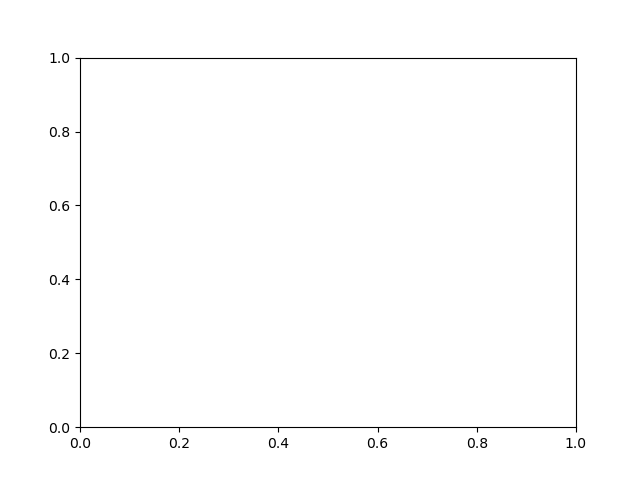

In [24]:
%matplotlib widget
plt.close('all')

energy_slice = slice(2470, 2480)
# energy_slice = slice(2470, None)

fig, ax = plt.subplots()
ord_nexafs.sel(energy=energy_slice).plot.line(ax=ax)
ext_nexafs.sel(energy=energy_slice).plot.line(ax=ax)
plt.show()
# plt.close('all')

### Try approach without fitting, just find minimum?

In [25]:
def mse(cos_sq_theta, e_min, e_max, nexafs, nexafs_fit, targ):
    #compose new extrapolated nexafs based on proposed cos_sq_theta 
    nexafs_new = nf.evaluate_nexafs_fit(nexafs, nexafs_fit, [cos_sq_theta[0]], [0])
    #evaluate the difference in area between the extrapolated nexafs and the taget targ
    mse = (nf.int_area(e_min, e_max, nexafs_new.electron_yield)-targ)**2
    minval = nexafs_new.sel(energy = slice(e_min,e_max)).electron_yield.min().values
    if minval < 0.005: #impose penalty for negative absorbance values
        mse = 1E10*mse*np.abs(minval)

    # beyond the at 2474, minimum value should not dip below 1
    in_edge_minval = nexafs_new.sel(energy = slice(2474, 2476)).electron_yield.min().values
    if in_edge_minval < 1.7: #impose penalty for negative absorbance values
        mse = 1E10*mse*np.abs(in_edge_minval)
    return mse

In [26]:
cossqtheta_o_rows = []
cossqtheta_e_rows = []
magic_nf_rows = []

e_min = 2471
e_max = 2473.8

for sample_ID in tqdm(nf_DA.sample_ID.values):
    DA = nf_ep_DA.sel(sample_ID=sample_ID).copy()
    
    nexafs = DA.copy()
    nexafs_fit = nexafs.polyfit('cos_sq_theta', 1)

    res_o = optimize.differential_evolution(mse, [(-1, 1)], args = (e_min, e_max, nexafs, nexafs_fit, 0), tol=1e-6)
    cossqtheta_o = float(res_o.x[0])
    cossqtheta_o_rows.append(cossqtheta_o)
    
    magic_nf = nf.evaluate_nexafs_fit(nexafs, nexafs_fit, [0.329], [55]).electron_yield
    magic_nf_rows.append(magic_nf)
    
    magic_int = nf.int_area(e_min, e_max, magic_nf)
    ord_int = nf.int_area(e_min, e_max, nf.evaluate_nexafs_fit(nexafs, nexafs_fit, [cossqtheta_o], [0]).electron_yield)
    e_targ = magic_int + 2*(magic_int-ord_int)

    # For perfectly face on, the extraordinary intensity should be exactly 3x magic intensity
    # This fit tends to be faster
    res_e = optimize.minimize(mse, 1, method='Nelder-Mead', args = (e_min, e_max, nexafs, nexafs_fit, e_targ), tol=1e-6)
    cossqtheta_e = float(res_e.x[0])    
    cossqtheta_e_rows.append(cossqtheta_e)

  0%|          | 0/9 [00:00<?, ?it/s]

Exception ignored in: <function tqdm.__del__ at 0x14e62bf60>
Traceback (most recent call last):
  File "/Users/andrew/conda_install/envs/kkcalc/lib/python3.12/site-packages/tqdm/std.py", line 1147, in __del__
    def __del__(self):

KeyboardInterrupt: 


KeyboardInterrupt: 

In [ ]:
cossqtheta_o_rows

In [ ]:
sorted(sn.keys())

In [ ]:
mol_fits

In [ ]:
# do this for a finely spaced values of theta...

nf_mol_DA_rows = []

sample_IDs = sorted(sn.keys())

for i, mol_fits in enumerate(zip(cossqtheta_o_rows, cossqtheta_e_rows)):
    mol_fits = list(mol_fits)

    num_fits = 100
    fine_mol_fits = np.linspace(mol_fits[0], mol_fits[1], num_fits)
    fine_theta = np.linspace(90, 0, num_fits)
    
    DA = nf_DA.sel(sample_ID=sample_IDs[i]).copy()
    magic_nf_DA = magic_nf_rows[i].swap_dims({'cos_sq_theta':'theta'})
    
    sample_name = sn[sample_IDs[i]]
    nexafs = DA.copy().swap_dims({'theta':'cos_sq_theta'}).squeeze()
    nexafs_fit = nexafs.polyfit('cos_sq_theta', 1)
    
    nexafs_mol = nf.evaluate_nexafs_fit(nexafs, nexafs_fit, fine_mol_fits, fine_theta)

    nf_mol_DA = nexafs_mol.electron_yield.swap_dims({'cos_sq_theta':'theta'}).rename('extrap_mol_nexafs')
    # nf_mol_DA = xr.concat([nf_mol_DA, magic_nf_DA], dim='theta').sortby('theta')
    # nf_mol_DA = nf_mol_DA.expand_dims({'sample_name': [sample_name]})
    nf_mol_DA = nf_mol_DA.expand_dims({'sample_ID': [sample_IDs[i]]})
    nf_mol_DA_rows.append(nf_mol_DA)


In [ ]:
%matplotlib inline
plt.close('all')

In [ ]:
whos PosixPath

In [ ]:
PM6_5CN_nf_mol_DA = xr.concat(nf_mol_DA_rows, dim='sample_ID').sel(sample_ID='SiN-4')
PM6_5CN_nf_mol_DA.to_dataset(name='extrapolated_nexafs')

In [ ]:
savePath = basePath.joinpath('local_data/trexs_nexafs_2024C3/waxs_all/extrap_nexafs_zarrs')
PM6_5CN_nf_mol_DA.to_dataset(name='extrapolated_nexafs').to_zarr(savePath.joinpath('PM6_5CN-CF_extrap_nexafs_v1.zarr'), mode='w')

In [ ]:
%matplotlib inline
plt.close('all')

colors = plt.cm.plasma(np.linspace(0,0.95,len(nf_mol_DA_rows[0].theta)))

energy_slice = slice(2470, 2480)
# energy_slice = slice(None, None)

for nf_mol_DA in nf_mol_DA_rows:
    fig, ax = plt.subplots()
    for i, theta_val in enumerate(nf_mol_DA.theta.values):
        nf_mol_DA.sel(energy=energy_slice, theta=theta_val).plot(color=colors[i], ax=ax)
    ax.set_title(sn[nf_mol_DA.sample_ID.values[0]])
    plt.show()
    # plt.close('all')

In [ ]:
nf_epmol_DA = xr.concat(nf_mol_DA_rows, dim='sample_ID')  #.sel(sample_ID='SiN-4')

In [ ]:
nf_epmol_DA

In [ ]:
%matplotlib inline
plt.close('all')

# Plot all incident angles NEXAFS for each sample

# Select energy slice(s)
# e_slice = slice(None, None)
e_slice = slice(2445, 2520)
# e_slice = slice(2470, 2495)
# e_slice = slice(2470, 2480)


# colors = plt.cm.viridis_r(np.linspace(0.1,1,3))
colors = plt.cm.plasma_r(np.linspace(0.1,1,4))
for sample_ID in tqdm(nf_epmol_DA.sample_ID.values[:]):
    fig, ax = plt.subplots(figsize=(5, 3), tight_layout=True, dpi=150)
    for i, theta in enumerate([0, 35, 55, 90]):
        # Plot    
        nf_epmol_DA.sel(sample_ID=sample_ID, energy=e_slice).sel(theta=theta, method='nearest').plot.line(ax=ax, label=f'{theta}°', color=colors[i])
                                                                        # linestyle='none', marker='.')

    ax.set_title(f'Extrapolated fluorescence NEXAFS: {sn[sample_ID]}')
    ax.set(ylabel=f'Intensity [arb. units]', xlabel='Energy [eV]')

    ax.xaxis.set_minor_locator(MultipleLocator(5))
    
    # ax.xaxis.set_minor_locator(MultipleLocator(1))
    # ax.xaxis.set_major_locator(MultipleLocator(2))
    ax.xaxis.grid(True, which='both')
    ax.legend(title='$\\theta$')

    savePath = basePath.joinpath('trexs_plots/2024C3/waxs_all/mol_nexafs_v1')
    savePath.mkdir(exist_ok=True)
    fig.savefig(savePath.joinpath(
        f'{sn_id[sample_ID]}_avg-roi-nexafs_energy-{e_slice.start}-{e_slice.stop}.png'), dpi=150)

    plt.show()
    plt.close('all')